# Deep Computer Vision Using Convolutional Neural Network
## Convolutional Layers Using Keras

In [1]:
from sklearn.datasets import load_sample_images
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.types.experimental import TensorLike

In [2]:
images = load_sample_images()['images']
images = tf.keras.layers.CenterCrop(height= 70, width= 120)(images)
images = tf.keras.layers.Rescaling(scale= 1/255)(images)

In [3]:
images.shape

TensorShape([2, 70, 120, 3])

2 -> There are two sample images (batch size) <br>
427 x 640 -> dimensions of images, (70 x 120 after croping) <br>
3 -> RGB Vector (number of channels of colors)

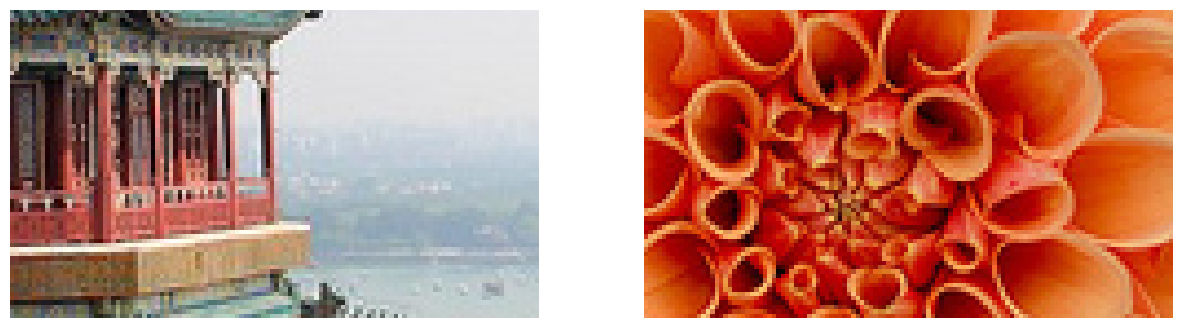

In [4]:
plt.figure(figsize= (15, 9))

plt.subplot(121)
plt.imshow(images[0])
plt.axis('off')

plt.subplot(122)
plt.imshow(images[1])
plt.axis('off')

plt.show()

In [5]:
conv_layer = tf.keras.layers.Conv2D(filters= 32, kernel_size= (7, 7))
feature_maps = conv_layer(images)

In [6]:
feature_maps.shape

TensorShape([2, 64, 114, 32])

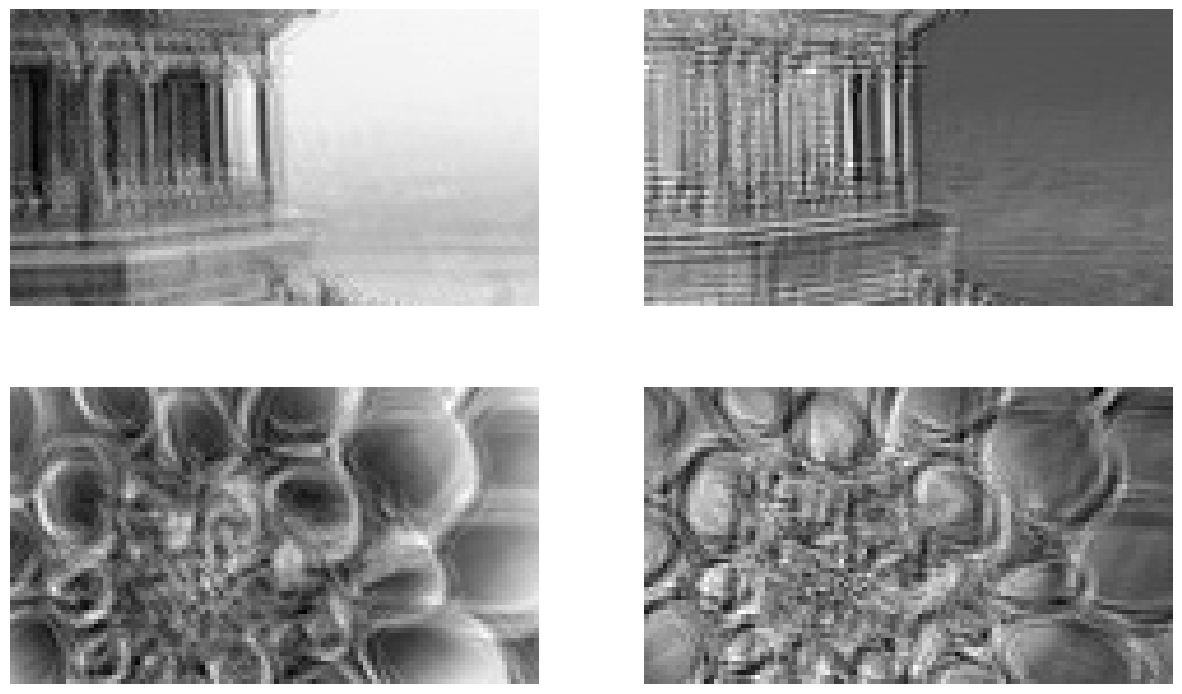

In [7]:
plt.figure(figsize= (15, 9))

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(feature_maps[image_idx, :, :, fmap_idx], cmap= 'gray')
        plt.axis('off')

plt.show()

In [8]:
conv_layer = tf.keras.layers.Conv2D(filters= 32, kernel_size= (7, 7), padding= 'same')
feature_maps = conv_layer(images)
feature_maps.shape

TensorShape([2, 70, 120, 32])

In [9]:
kernels, biases = conv_layer.get_weights()

In [10]:
kernels.shape

(7, 7, 3, 32)

In [11]:
biases.shape

(32,)

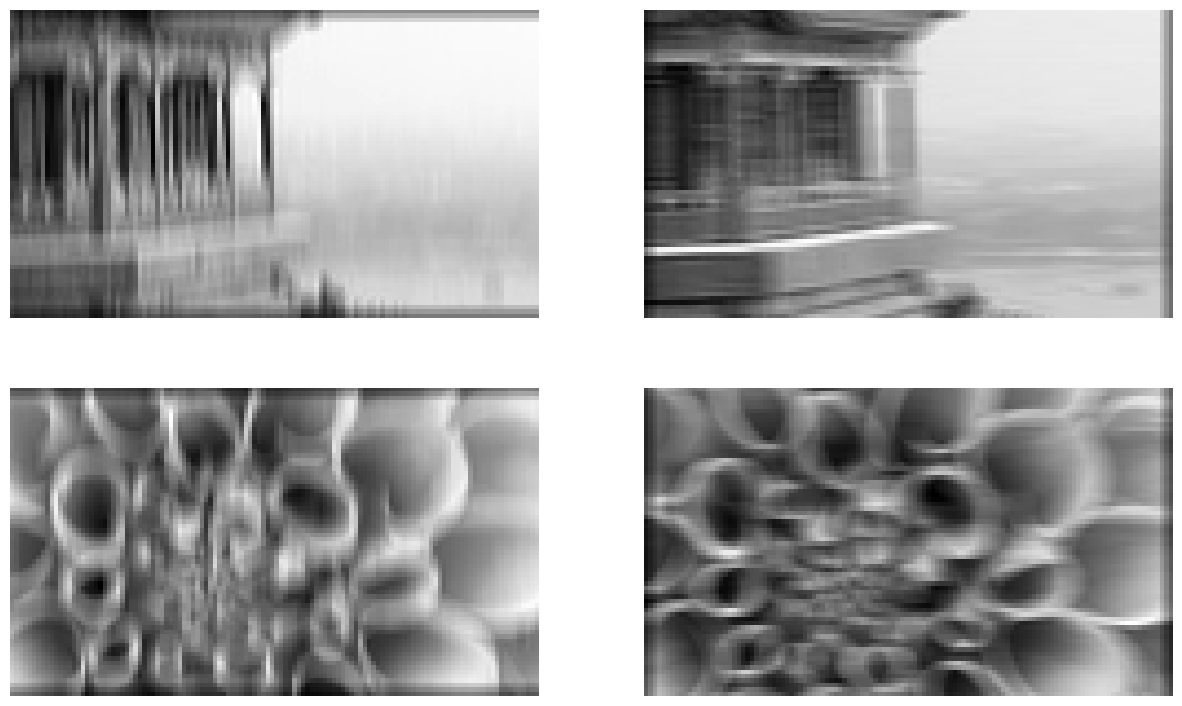

In [12]:
# Making proper horizontal and vertical edge detector and also how to use tf.nn.conv2d

biases = tf.zeros([2])    # [2] -> output_shape
filters = np.zeros([7, 7, 3, 2])   # in general, we randomly initialize. [kernel_height, kernel_width, input_shape, output_shape]
filters[:, 3, :, 0] = 1    # vertical edge detector    # took 3 because it is center for index= 7
filters[3, :, :, 1] = 1    # horizontal edge detector
feature_maps = tf.nn.conv2d(images, filters, strides= 1, padding= 'SAME') + biases    # Conv2D using tf.nn

plt.figure(figsize= (15, 9))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(feature_maps[image_idx, :, :, fmap_idx], cmap= 'gray')
        plt.axis('off')
plt.show()

## Pooling Layers
### Max Pooling

In [13]:
max_pool = tf.keras.layers.MaxPool2D(pool_size= 2)

In [14]:
output = max_pool(images)

In [15]:
output.shape    # just half of original images size

TensorShape([2, 35, 60, 3])

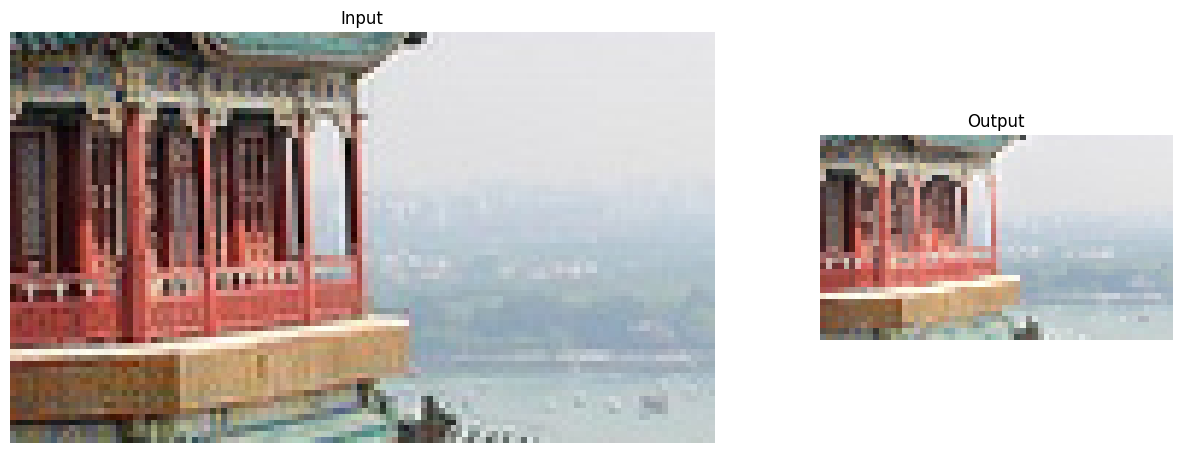

In [16]:
import matplotlib as mpl

fig = plt.figure(figsize= (15, 9))
gs = mpl.gridspec.GridSpec(nrows= 1, ncols= 2, width_ratios= [2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title('Input')
ax1.imshow(images[0])
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title('Output')
ax2.imshow(output[0])
ax2.axis('off')

plt.show()

In [17]:
gs[0, 0], gs[0, 1]

(GridSpec(1, 2, width_ratios=[2, 1])[0:1, 0:1],
 GridSpec(1, 2, width_ratios=[2, 1])[0:1, 1:2])

### Average Pooling

In [18]:
avg_pool = tf.keras.layers.AveragePooling2D(pool_size= 2)
output = avg_pool(images)

In [19]:
output.shape

TensorShape([2, 35, 60, 3])

### Depth-wise Pooling

In [20]:
class DepthPool(tf.keras.layers.Layer):
    def __init__(self, pool_size: int = 2, **kwargs) -> None:
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs: TensorLike) -> tf.Tensor:
        shape = tf.shape(inputs)
        groups = shape[-1] // self.pool_size
        new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis= 0)
        return tf.reduce_max(tf.reshape(inputs, new_shape), axis= -1)

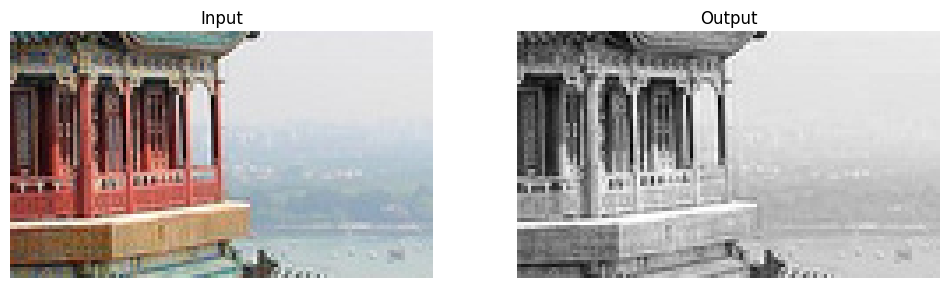

In [21]:
depth_output = DepthPool(pool_size= 3)(images[0])

plt.figure(figsize= (12, 8))
plt.subplot(121)
plt.title('Input')
plt.imshow(images[0])
plt.axis('off')
plt.subplot(122)
plt.title('Output')
plt.imshow(depth_output, cmap= 'gray')
plt.axis('off')
plt.show()

### Global Average Pooling

In [22]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

In [23]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.643388  , 0.59718215, 0.5825038 ],
       [0.7630747 , 0.26010972, 0.10848834]], dtype=float32)>

In [24]:
global_avg_pool = tf.keras.layers.Lambda(lambda X: tf.reduce_mean(X, axis= [1, 2]))

In [25]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.643388  , 0.59718215, 0.5825038 ],
       [0.7630747 , 0.26010972, 0.10848834]], dtype=float32)>

## CNN Architectures

In [26]:
from functools import partial

In [27]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
X_train_full = np.expand_dims(X_train_full, axis= -1).astype(np.float32) / 255.
X_test = np.expand_dims(X_test, axis= -1).astype(np.float32) / 255.
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [28]:
[arr.shape for arr in (X_train, y_train, X_valid, y_valid, X_test, y_test)]

[(55000, 28, 28, 1),
 (55000,),
 (5000, 28, 28, 1),
 (5000,),
 (10000, 28, 28, 1),
 (10000,)]

In [29]:
tf.random.set_seed(42)

DefaultConv2D = partial(
    tf.keras.layers.Conv2D,
    kernel_size= 3,
    padding= 'same',
    activation= 'relu',
    kernel_initializer= 'he_normal'
)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape= [28, 28, 1]),
    
    DefaultConv2D(filters= 64, kernel_size= 7),
    tf.keras.layers.MaxPool2D(),
    
    DefaultConv2D(filters= 128),
    DefaultConv2D(filters= 128),
    tf.keras.layers.MaxPool2D(),

    DefaultConv2D(filters= 256),
    DefaultConv2D(filters= 256),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation= 'relu', kernel_initializer= 'he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(64, activation= 'relu', kernel_initializer= 'he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10, activation= 'softmax')
])

In [30]:
model.compile(
    optimizer= 'adam',
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs= 10,
    validation_data= (X_valid, y_valid)
)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5299 - loss: 1.2603 - val_accuracy: 0.8614 - val_loss: 0.3884
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8301 - loss: 0.4993 - val_accuracy: 0.8958 - val_loss: 0.2968
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8641 - loss: 0.3909 - val_accuracy: 0.8960 - val_loss: 0.2901
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8860 - loss: 0.3440 - val_accuracy: 0.9032 - val_loss: 0.2892
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8955 - loss: 0.3055 - val_accuracy: 0.9106 - val_loss: 0.2514
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9045 - loss: 0.2788 - val_accuracy: 0.9032 - val_loss: 0.2807
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9105 - loss: 0.2686 - val_accuracy: 0.9124 - val_loss: 0.2705
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9125 - loss: 0.2528 -

In [32]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9045 - loss: 0.2913


[0.28403282165527344, 0.9089000225067139]